In [22]:
import argparse
import csv
import math
import os
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from pathlib import Path
import pandas as pd
import seaborn as sns

# Set working directory to project root (so paths like "results/..." work)
project_root = Path.cwd().parent if (Path.cwd() / "plots.ipynb").exists() else Path.cwd()
print(project_root)
os.chdir(project_root)

COLORS = {'jpeg': 'tab:blue', 'turbo_ddcm': 'red', 'robust_turbo_ddcm': 'orange', 'ddcm': 'green', 'bpg': 'purple'}
MARKERS = {'jpeg': 'o', 'turbo_ddcm': 's', 'robust_turbo_ddcm': 'D', 'ddcm': '^', 'bpg': 'v'}
LABELS = {'jpeg': 'JPEG', 'turbo_ddcm': 'Turbo-DDCM', 'robust_turbo_ddcm': 'Robust Turbo-DDCM', 'ddcm': 'DDCM', 'bpg': 'BPG'}
SUBTITLES = {'psnr' : 'PSNR \\uparrow', 'lpips' : 'LPIPS \\downarrow', 'fid' : 'FID \\downarrow',
             'niqe' : 'NIQE \\downarrow', 'failed_ind' : '\% Corrupted Files \\downarrow'}
DATASET_TITLES = {
    "Kodak24_512" : r"$\mathrm{Kodak24}_{512}$",
    "DIV2K_512" : r"$\mathrm{DIV2K}_{512}$",
    "DIV2K_valid_HR_512" : r"$\mathrm{DIV2K}_{512}$",
}
# Map folder name (args['dataset_name']) to DATASET_TITLES key
DATASET_FOLDER_TO_TITLE = {
    "dataset_Kodak24": "Kodak24_512",
    "DIV2K_valid_HR_512": "DIV2K_512",
}

plt.rcParams['font.family'] = 'serif'
plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams.update({
    'font.size': 16,          # base font size
    'axes.titlesize': 20,     # title size
    'axes.labelsize': 18,     # x and y label size
    'xtick.labelsize': 18,    # x tick size
    'ytick.labelsize': 18,    # y tick size
    'legend.fontsize': 18     # legend size
})

def tex_label(text: str) -> str:
    """Wrap plain text into LaTeX mathrm with escaped spaces."""
    return r"$\mathrm{" + text.replace(" ", r"\ ") + "}$"

/home/galkesten/Diffusion-Compression-Editing-Attacks


In [23]:
# config
args = {}
args['methods'] = ['jpeg', 'turbo_ddcm', 'robust_turbo_ddcm', 'ddcm', 'bpg']
#args['methods'] = ['jpeg', 'turbo_ddcm', 'robust_turbo_ddcm']
#args['dataset_name'] = 'dataset_Kodak24'  # or 'DIV2K_valid_HR_512', etc.
args['dataset_name'] = 'DIV2K_valid_HR_512'
args['ber_min'] = 1e-6
args['ber_max'] = 1

In [24]:
results_df = pd.DataFrame()
dataset_name = args['dataset_name']
for method in args['methods']:
    base = f'results/noisy_channel/{method}/{dataset_name}'
    print(base)
    current_df = pd.read_csv(f'{base}/noisy_channel_{method}.csv')
    current_df_fid = pd.read_csv(f'{base}/fid_{method}.csv')
    current_df = current_df.merge(current_df_fid, on=['ber', 'trial'], validate='m:1')

    assert ((current_df['error'].notna()) | (current_df['psnr'].notna())).all()
    current_df['failed_ind'] = current_df['error'].notna()

    current_df['method'] = method
    results_df = pd.concat([results_df, current_df])

results_df = results_df.reset_index()
results_df = results_df[results_df['ber'].between(args['ber_min'], args['ber_max'])]

results/noisy_channel/jpeg/DIV2K_valid_HR_512
results/noisy_channel/turbo_ddcm/DIV2K_valid_HR_512
results/noisy_channel/robust_turbo_ddcm/DIV2K_valid_HR_512
results/noisy_channel/ddcm/DIV2K_valid_HR_512
results/noisy_channel/bpg/DIV2K_valid_HR_512


/tmp/ipykernel_154019/827675628.py:68: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


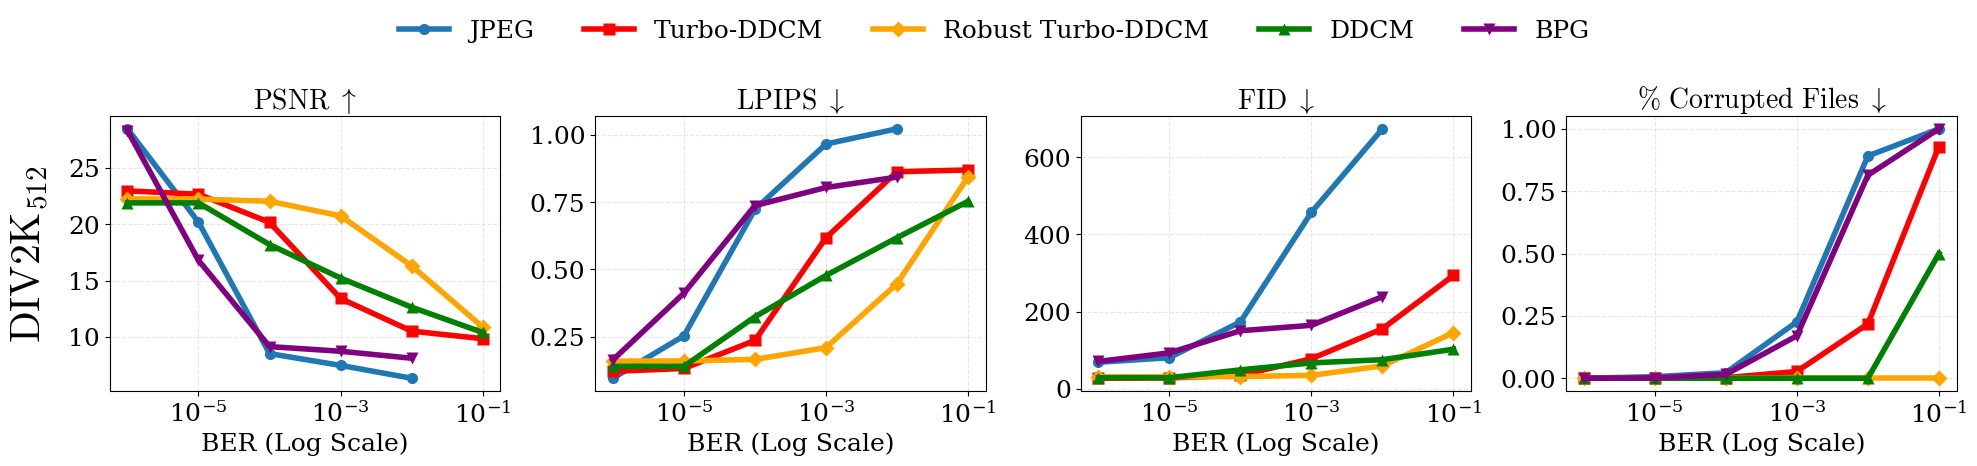

In [25]:
x_field = 'ber'
hue_field_name = 'method'
metrics_to_plot = ["psnr", "lpips", "fid", "failed_ind"]
# Derive datasets from args['dataset_name'] (folder name -> DATASET_TITLES key)
datasets = [DATASET_FOLDER_TO_TITLE.get(args['dataset_name'], args['dataset_name'])]
n_rows = len(datasets)
n_cols = len(metrics_to_plot)

fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(5 * n_cols, 4.2 * n_rows),
                         sharex=True, constrained_layout=True)

if n_rows == 1:
    axes = [axes]
elif n_cols == 1:
    axes = [[ax] for ax in axes]

legend_ax = None
for row_idx, dataset_name in enumerate(datasets):
    # df_subset = results_df[(results_df["dataset"] == dataset_name)]
    for col_idx, metric in enumerate(metrics_to_plot):
        ax = axes[row_idx][col_idx]

        sns.lineplot(
            data=results_df,
            x=x_field,
            y=metric,
            hue=hue_field_name,
            marker='o',
            errorbar=None, # (ci_pi, confidence_level),
            ax=ax,
            style=hue_field_name,
            markers=MARKERS,
            dashes=False,
            palette=COLORS,
            linewidth=4,
            markersize=8,
            markeredgecolor="none"
        )

        if legend_ax is None:
            legend_ax = ax
        ax.get_legend().remove()

        ax.set_xscale('log')
        ax.grid(True, linestyle="--", alpha=0.3)
        ax.set_ylabel(None)
        ax.set_xlabel('BER (Log Scale)')

        # Column titles on top row
        if row_idx == 0:
            ax.set_title(tex_label(SUBTITLES[metric]))

    axes[row_idx][0].text(-0.15, 0.5, DATASET_TITLES[dataset_name], va="center", ha="right",
                          fontsize=30, rotation=90, transform=axes[row_idx][0].transAxes)


handles, labels = legend_ax.get_legend_handles_labels()
labels = [LABELS[label] for label in labels]
fig.legend(
    handles, labels,
    loc="upper center",
    ncol=len(labels),
    bbox_to_anchor=(0.5, 1.15),
    frameon=False,
    fontsize = 18
)

plt.tight_layout()
plt.show()

# output_path = os.path.join(output_dir, f'{metric.lower()}_averaged.pdf')
# plt.savefig(output_path, dpi=300, bbox_inches='tight')
# print(f"Saved: {output_path}")


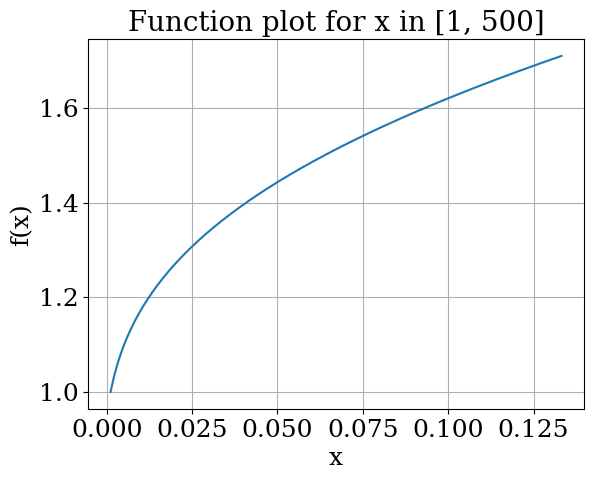

In [20]:
import numpy as np
import matplotlib.pyplot as plt

K = 16384

def f(x):
    numerator = np.log2(K) * x + x
    denominator = math.log2(math.comb(K, x)) + x
    return numerator / denominator

def bpp(x):
    return 20*(math.log2(math.comb(K, x)) + x) / (512**2)

# x range (exclude 0 because denominator becomes 0)
x_vals = np.arange(1, 200)
y_vals = [f(x) for x in x_vals]
x_vals = [bpp(x) for x in x_vals]

# Plot
plt.figure()
plt.plot(x_vals, y_vals)
plt.xlabel("x")
plt.ylabel("f(x)")
plt.grid(True)
plt.title("Function plot for x in [1, 500]")
plt.show()

In [21]:
x_vals.index(np.float64(0.10040459256624501))

ValueError: 0.10040459256624501 is not in list

In [ ]:
20*(math.log2(math.comb(K, 100)) + 100) # / (512**2)

19495.964976779676